## Human lung cancer perturbation

Edit input, checkpoint, and output paths in `perturb/config.yaml`. Review intervention settings below, then run from top to bottom.


In [1]:
from pathlib import Path
import os, sys, glob, json, inspect, copy
sys.dont_write_bytecode = True
EXPERIMENT_DIR = next(q for p in [Path.cwd(), *Path.cwd().parents] for q in [p, p/'human_lung_cancer', p/'experiments/human_lung_cancer'] if q.name == 'human_lung_cancer' and (q/'perturb/config.yaml').is_file())
PERTURB_DIR = EXPERIMENT_DIR / 'perturb'
sys.path.insert(0, str(EXPERIMENT_DIR.parents[1] / 'src'))
from stvirtual.perturb import prepare_runtime
prepare_runtime(EXPERIMENT_DIR)
import scanpy as sc
import torch
import numpy as np
import pandas as pd
import anndata as ad
import scvi
import scipy.sparse as sp
from scipy import sparse
import torch.nn.functional as F
import matplotlib.pyplot as plt
from stvirtual.perturb import PerturbationSession, read_frames, find_gene_name
session = PerturbationSession('LUAD', config_path=PERTURB_DIR/'config.yaml')
paths = session.paths


In [2]:
adata = session.input()
adata

AnnData object with n_obs × n_vars = 216236 × 18085
    obs: 'cx', 'cy', 'layer_idx', 'layer_name', 'uid', 'parent_uid', 'is_birth', 'is_diff', 'diff_alpha', 'diff_tgt_layer', 'diff_tgt_layer_name', 'sample', 'frame', 'x_roll', 'y_roll', 't'
    uns: 'is_birth_colors', 'is_diff_colors', 'layer_name_colors', 'neighbors', 'umap'
    obsm: 'X_latent', 'X_umap', 'spatial'
    layers: 'counts_hat'
    obsp: 'connectivities', 'distances'

In [3]:
data_path = str(Path(paths['input']).parent)
ckpt_path = str(Path(paths['stage1']).parents[3])
resl_path = str(session.output)
lrpr_path = paths['lr_pairs']
diff_path = paths['diff_map']
sta1_path = paths['stage1']
sta2_path = paths['stage2']


In [4]:
perturb_num = 10
route_ids=['AAH', 'LUAD']
fracs = ['AAH_to_LUAD']
seg_key = "AAH_to_LUAD"
steps = 100

In [5]:
stage1_ckpt = torch.load(sta1_path, map_location='cpu', weights_only=False)
stage2_ckpt = torch.load(sta2_path, map_location='cpu', weights_only=False)
print(stage1_ckpt.keys()); print(stage2_ckpt.keys())

dict_keys(['epoch', 'best', 'net', 'opt', 'global_norm', 'wfr_hparams', 'ode_hparams', 'guide_hparams', 'loss_hparams'])
dict_keys(['epoch', 'model_state', 'alpha_state', 'best_reward', 'grid_size', 'advect_latent', 'T', 'use_lr', 'policy_args', 'alpha_args'])


In [6]:
model_dir = paths['scanvi']
model = session.scanvi()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/checkpoints/luad_ckpt/sub_scvi/scanvi/model.pt already downloaded                       


In [7]:
deg_path = EXPERIMENT_DIR / 'data/deg_up_sig.csv'
up_sig = pd.read_csv(deg_path,index_col=0) if deg_path.exists() else pd.DataFrame()
up_sig

,scores,logFC,pval,pval_adj,pct_nz_group,neglog10_padj,abs_logFC
gene,,,,,,,
SLC30A3,6.920994,0.272104,4.484849e-12,1.158693e-08,0.969793,7.936032,0.272104
DACT2,6.810051,0.580020,9.756390e-12,2.205554e-08,0.914149,7.656482,0.580020
PRSS33,6.781156,0.287378,1.192178e-11,2.395616e-08,0.965024,7.620583,0.287378
TTLL8,6.559806,0.333758,5.387791e-11,9.743819e-08,0.985692,7.011271,0.333758
MZB1,6.473656,0.424359,9.565977e-11,1.330775e-07,1.000000,6.875895,0.424359


In [8]:
# Default condition uses seeded random genes; DEG ranking is optional.


## Select genes and suppress expression

Apply expression suppression to AAH cells and use `X_scanvi_pert` for the perturbed representation.


In [9]:
seed = int(session.config.get('seed',2025))
rng = np.random.default_rng(seed)
gene_list = session.config.get('genes') or rng.choice(adata.var_names.to_numpy(),size=int(session.config.get('random_gene_count',10)),replace=False).tolist()
perturb_num = len(gene_list)
print(gene_list)


['SIK3', 'ZNF790', 'STK38', 'SYT13', 'WWTR1', 'PLA2G1B', 'ZNF74', 'ZNF281', 'KRTDAP', 'HS3ST2']


In [10]:
adata_ori = session.input()
adata_ori

AnnData object with n_obs × n_vars = 4280 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample_id', 'condition', 'patient', 'status', 'clone', 'tissue_need', '_sample_name', '_clone_s', '_scvi_batch', '_scvi_labels', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types'
    uns: '_clone_s_colors', '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'pca', 'sample_id_colors', 'status_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'spatial_aligned'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [11]:
adata_aah = adata_ori[adata_ori.obs['status']=='AAH']
adata_luad = adata_ori[adata_ori.obs['status']=='LUAD']
print(adata_aah)
print(adata_luad)

View of AnnData object with n_obs × n_vars = 806 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample_id', 'condition', 'patient', 'status', 'clone', 'tissue_need', '_sample_name', '_clone_s', '_scvi_batch', '_scvi_labels', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types'
    uns: '_clone_s_colors', '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'pca', 'sample_id_colors', 'status_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'spatial_aligned'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
View of AnnData object with n_obs × n_vars = 3474 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample_id', 'condition', 'patient', 'status', 'clone', 'tissue_need', '_sample_name', '_clone_s', '_scvi_batch', '_scvi_labels', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types'
    uns: '_clone_s_colors', '

In [12]:
# Initial expression suppression is implemented by the shared perturbation session.


In [13]:
adata_pert, perturb_report = session.apply_intervention(adata_ori, genes=gene_list)
perturb_report


[ok] total cells = 4280
[ok] perturbed cells = 683
[ok] zeroed genes = 10 in adata.X
[ok] selected _clone_s = ['4', '6']


In [14]:
genes_check = [g for g in gene_list if g in adata_pert.var_names]

sub = adata_pert[adata_pert.obs[session.config["celltype_key"]].astype(str).isin(session.config["celltypes"]), genes_check]

Xchk = sub.X if sparse.issparse(sub.X) else np.asarray(sub.X)
print("max =", Xchk.max(), "min =", Xchk.min())

max = 0.0 min = 0.0


In [15]:
genes_check = [g for g in gene_list if g in adata_pert.var_names]

mask = adata_pert.obs[session.config["celltype_key"]].astype(str).isin(session.config["celltypes"])
sub = adata_pert[mask, genes_check]

Xchk = sub.layers["counts"]
Xchk = Xchk 

print("shape =", Xchk.shape)
print("max =", Xchk.max(), "min =", Xchk.min())

shape = (683, 10)
max = 0.0 min = 0.0


In [16]:
adata_pert.obs["_clone_s"] = adata_pert.obs["_clone_s"].astype(str)
layer_str = adata_pert.obs["_clone_s"].astype(str)
aah_layers = {"0", "3", "4", "6"}
luad_layers = {"1", "2"}
adata_pert = session.reinfer(adata_pert, model=model)


Anndata setup with scvi-tools version 1.4.0.

Setup via `SCANVI.setup_anndata` with arguments:

{
│   'labels_key': '_clone_s',
│   'unlabeled_category': 'Unknown',
│   'layer': 'counts',
│   'batch_key': 'status',
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None,
│   'use_minified': True
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   2   │
│         n_cells          │ 4280  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   7   │
│          n_vars          │ 18085 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['status'] │    AAH     │          0          │
│                     │    LUAD    │          1          │
└─────────────────────┴────────────┴─────────────────────┘

                   labels State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_clone_s'] │     0      │          0          │
│                       │     1      │          1          │
│                       │     2      │          2          │
│                       │     3      │          3          │
│                       │     4      │          4          │
│                       │     6      │          5          │
│                       │  Unknown   │          6          │
└───────────────────────┴────────────┴─────────────────────┘

X:
  attr_key: counts
  attr_name: layers
batch:
  attr_key: _scvi_batch
  attr_name: obs
labels:
  attr_key: _scvi_labels
  attr_name: obs

INFO     Found 100.0% reference vars in query data.                                                                
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


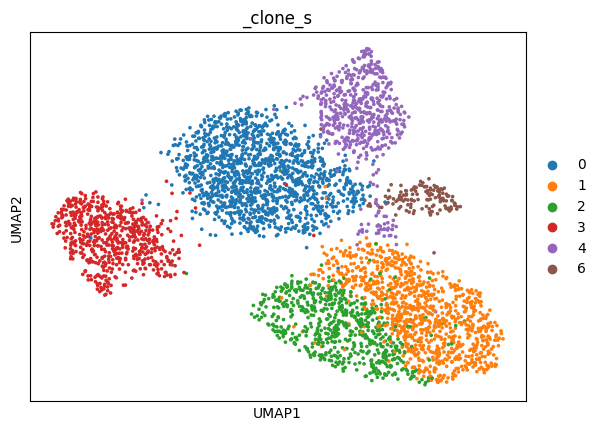

In [17]:
sc.pl.umap(adata_ori, color = '_clone_s')

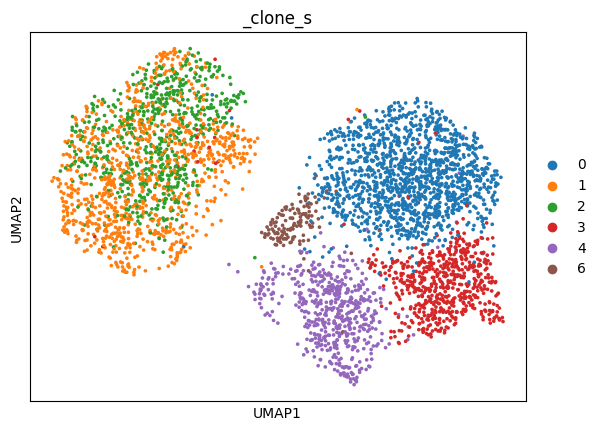

In [18]:
sc.pp.neighbors(adata_pert, use_rep="X_scanvi_pert")
sc.tl.umap(adata_pert)
sc.pl.umap(adata_pert, color = '_clone_s')

## Stage 1 and Stage 2 simulation

Run transport and transition inference from the perturbed source.


In [19]:
# Stage-1 inference uses the current public model and checkpoint schema.
transport = session.transport

In [20]:
adata_src = adata_pert[adata_pert.obs[session.config["sample_key"]].astype(str).eq(session.config["source"])].copy()
adata_tgt = adata_pert[adata_pert.obs[session.config["sample_key"]].astype(str).eq(session.config["target"])].copy()
print(adata_src)
print(adata_tgt)


View of AnnData object with n_obs × n_vars = 806 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample_id', 'condition', 'patient', 'status', 'clone', 'tissue_need', '_sample_name', '_clone_s', '_scvi_batch', '_scvi_labels', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types'
    uns: '_clone_s_colors', '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'pca', 'sample_id_colors', 'status_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'spatial_aligned', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
View of AnnData object with n_obs × n_vars = 3474 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample_id', 'condition', 'patient', 'status', 'clone', 'tissue_need', '_sample_name', '_clone_s', '_scvi_batch', '_scvi_labels', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types'
    uns: '_c

In [21]:
res1_zs = session.transport(adata_src, adata_tgt)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


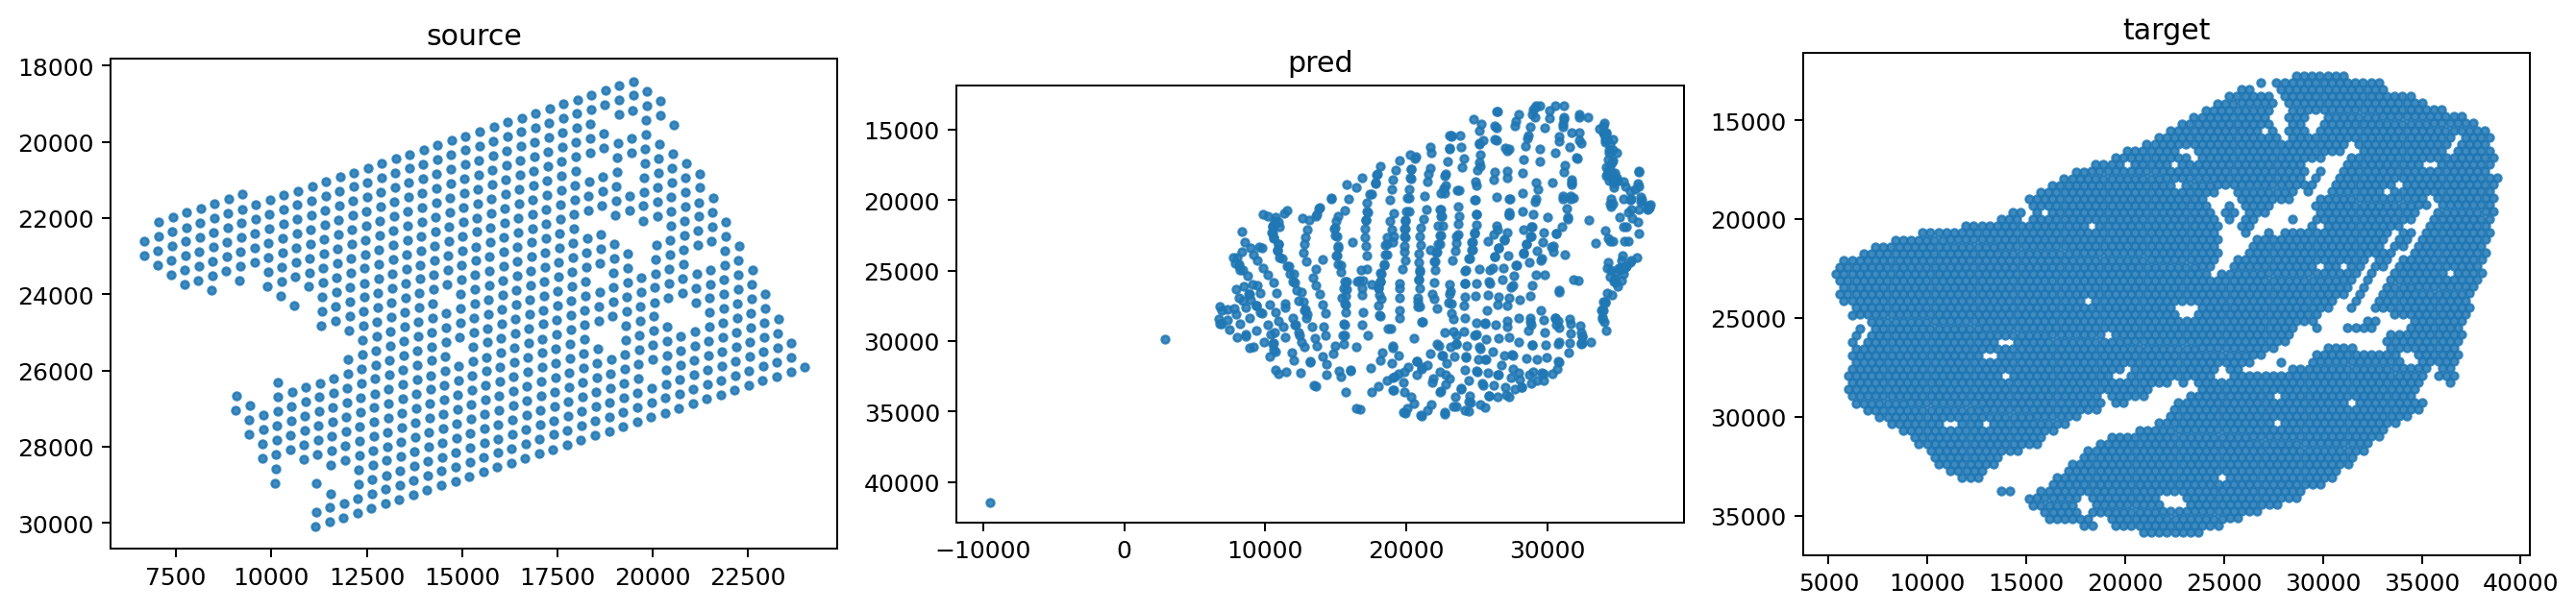

In [22]:
import numpy as np
import matplotlib.pyplot as plt

X0 = res1_zs["coords0"].detach().cpu().numpy()
X1 = res1_zs["x1"].detach().cpu().numpy()
XT = res1_zs["coords_tgt"].detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=180)

axes[0].scatter(X0[:, 0], X0[:, 1], s=10, alpha=0.85)
axes[0].set_title("source")

axes[1].scatter(X1[:, 0], X1[:, 1], s=10, alpha=0.85)
axes[1].set_title("pred")

axes[2].scatter(XT[:, 0], XT[:, 1], s=10, alpha=0.85)
axes[2].set_title("target")

for ax in axes:
    ax.set_aspect("equal")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [23]:
# Stage-2 inference is handled by session.transition using the public interface.

In [24]:
# Stage preparation uses the current trace file and configured boundaries.

In [25]:
# Policy architecture is loaded by the current public transition model.

In [26]:
# Inference uses session.transition; no research model imports are required.

In [ ]:
session.save_input(adata_pert, session.start() / f"adata_pert_top{perturb_num}.h5ad")


In [ ]:
device = torch.device(session.device)
ctx, pack_lower, res2_zs = session.transition(adata_pert, res1_zs)
state_final = res2_zs['state_final']
coords_gen = state_final['coords']
layers_gen = state_final['layers']
latent_gen = state_final['latent']
alpha_gen = state_final['diff_alpha']


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


LOADING latent model from: /home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/checkpoints/luad_ckpt/sub_scvi/scanvi
INFO     File /home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/checkpoints/luad_ckpt/sub_scvi/scanvi/model.pt already downloaded                       
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
[Grid] H=60, W=84, H×W=5040


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


[auto cap] 2 {'src': {'q': 0.9, 'quantile_value': 1.0, 'mean': 0.9999999403953552, 'max': 1.0, 'n_cells_used': 803}, 'tgt': {'q': 0.9, 'quantile_value': 2.0, 'mean': 1.3792965412139893, 'max': 3.0, 'n_cells_used': 2502}, 'cap0': 1, 'capT': 2, 'cap': 2}
[diff] loaded /home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/diff_map.csv Kmax= 2


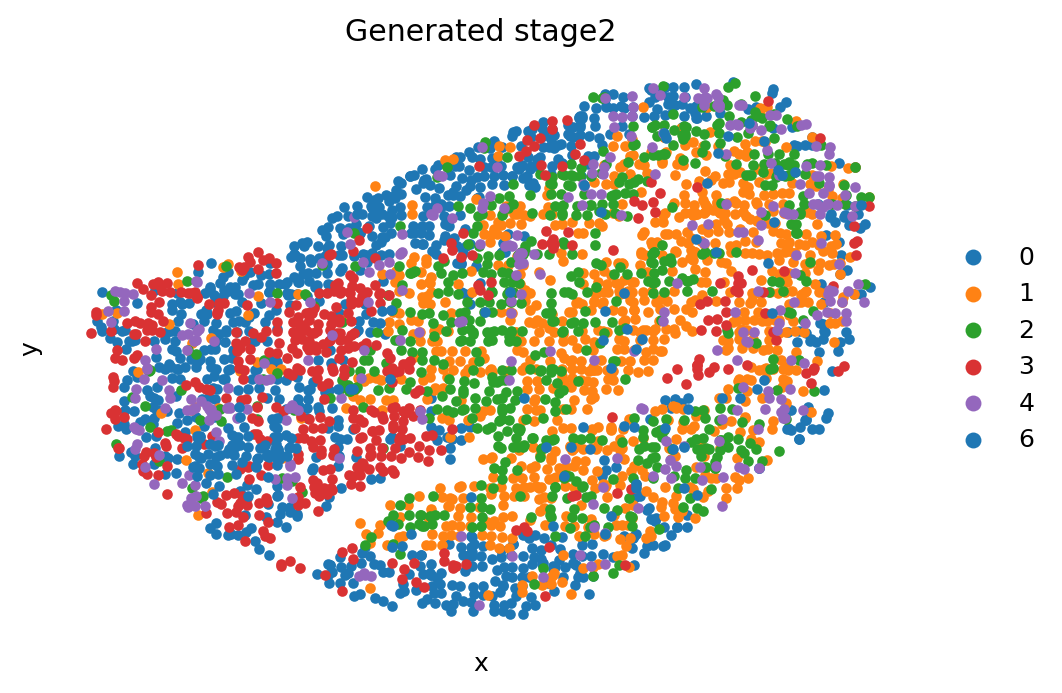

In [29]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ---------- 1) Convert to numpy. ----------
def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

coords_gen_np = to_np(coords_gen)
layers_gen_np = to_np(layers_gen).astype(int)

# Include source and target for comparison.
coords_src_np = to_np(pack_lower.state0["coords"])
layers_src_np = to_np(pack_lower.state0["layers"]).astype(int)

coords_tgt_np = to_np(pack_lower.target_state["coords"])
layers_tgt_np = to_np(pack_lower.target_state["layers"]).astype(int)

# ---------- 2) Map layer indices to names. ----------
if hasattr(ctx, "layers_list") and ctx.layers_list is not None:
    idx_to_layer = {i: str(x) for i, x in enumerate(ctx.layers_list)}
else:
    all_idx = np.unique(np.concatenate([layers_src_np, layers_tgt_np, layers_gen_np]))
    idx_to_layer = {int(i): str(i) for i in all_idx}

layer_name_gen = np.array([idx_to_layer.get(int(i), str(i)) for i in layers_gen_np], dtype=object)
layer_name_src = np.array([idx_to_layer.get(int(i), str(i)) for i in layers_src_np], dtype=object)
layer_name_tgt = np.array([idx_to_layer.get(int(i), str(i)) for i in layers_tgt_np], dtype=object)

# ---------- 3) Colors. ----------
cluster_color_map = {
    "0": "#1F77B4",
    "1": "#FF8214",
    "2": "#2CA02C",
    "3": "#D93233",
    "4": "#9467BD",
    "5": "#905B51",
}

all_names = sorted(set(layer_name_src) | set(layer_name_tgt) | set(layer_name_gen), key=lambda x: (x not in cluster_color_map, x))
fallback_colors = plt.cm.tab20(np.linspace(0, 1, max(20, len(all_names))))
color_map = {}
j = 0
for name in all_names:
    if name in cluster_color_map:
        color_map[name] = cluster_color_map[name]
    else:
        color_map[name] = fallback_colors[j]
        j += 1

# ---------- 4) Single-panel plotting function. ----------
def plot_one(coords, labels, title="", s=16, alpha=0.95, invert_y=True, add_legend=True):
    plt.figure(figsize=(6, 6), dpi=180)
    for lab in all_names:
        m = (labels == lab)
        if np.any(m):
            plt.scatter(coords[m, 0], coords[m, 1], s=s, c=[color_map[lab]], label=lab, alpha=alpha, linewidths=0)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    if invert_y:
        plt.gca().invert_yaxis()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xticks([])
    plt.yticks([])
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    if add_legend:
        plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, markerscale=1.5)
    plt.tight_layout()
    plt.show()

# ---------- 5) Plot generated results first. ----------
plot_one(coords_gen_np, layer_name_gen, title="Generated stage2", s=18, alpha=1.0, invert_y=True, add_legend=True)

In [30]:
import numpy as np
import pandas as pd
import torch
import anndata as ad
import scipy.sparse as sp

def _to_np(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def build_history_adata_from_res2(res2_zs, ctx=None, include_latent=True):
    states = res2_zs["history"]["state"]
    if len(states) == 0:
        raise ValueError("res2_zs['history']['state'] is empty")

    idx_to_layer = None
    if ctx is not None and hasattr(ctx, "layers_list") and ctx.layers_list is not None:
        idx_to_layer = {i: str(x) for i, x in enumerate(ctx.layers_list)}

    obs_list = []
    latent_list = []
    spatial_norm_list = []
    spatial_list = []

    for t, st in enumerate(states):
        coords = _to_np(st["coords"]).astype(np.float32)
        n = coords.shape[0]

        layers = _to_np(st.get("layers", np.full(n, -1))).astype(np.int64)
        uid = _to_np(st.get("uid", np.arange(n))).astype(np.int64)
        parent_uid = _to_np(st.get("parent_uid", np.full(n, -1))).astype(np.int64)
        born_step = _to_np(st.get("born_step", np.full(n, -1))).astype(np.int32)

        is_diff = _to_np(st.get("is_diff", np.zeros(n, dtype=bool))).astype(bool)
        diff_alpha = _to_np(st.get("diff_alpha", np.zeros(n, dtype=np.float32))).astype(np.float32)
        diff_mid = _to_np(st.get("diff_mid", np.zeros(n, dtype=np.float32))).astype(np.float32)
        diff_tgt_layer = _to_np(st.get("diff_tgt_layer", np.full(n, -1))).astype(np.int64)
        diff_enter_step = _to_np(st.get("diff_enter_step", np.full(n, -1))).astype(np.int32)
        commit_step = _to_np(st.get("commit_step", np.full(n, -1))).astype(np.int32)

        lr = _to_np(st.get("lr", np.full(n, np.nan))).astype(np.float32)
        anchor = _to_np(st.get("anchor", np.full(n, -1))).astype(np.int64)

        if idx_to_layer is not None:
            layer_name = np.array([idx_to_layer.get(int(i), str(i)) for i in layers], dtype=object)
            diff_tgt_layer_name = np.array(
                [idx_to_layer.get(int(i), str(i)) if int(i) >= 0 else "none" for i in diff_tgt_layer],
                dtype=object
            )
        else:
            layer_name = layers.astype(str)
            diff_tgt_layer_name = np.where(diff_tgt_layer >= 0, diff_tgt_layer.astype(str), "none")

        late_prob = np.clip(diff_alpha - 0.5 * diff_mid, 0.0, 1.0).astype(np.float32)

        obs = pd.DataFrame({
            "frame": t,
            "uid": uid,
            "parent_uid": parent_uid,
            "born_step": born_step,
            "anchor": anchor,
            "layer_idx": layers,
            "layer_name": layer_name,
            "is_diff": is_diff,
            "diff_alpha": diff_alpha,
            "diff_mid": diff_mid,
            "late_prob": late_prob,
            "diff_tgt_layer_idx": diff_tgt_layer,
            "diff_tgt_layer_name": diff_tgt_layer_name,
            "diff_enter_step": diff_enter_step,
            "commit_step": commit_step,
            "lr": lr,
        }, index=[f"f{t:03d}_uid{int(u)}" for u in uid])

        obs_list.append(obs)
        spatial_norm_list.append(coords)

        if ctx is not None and hasattr(ctx, "xy_mu") and hasattr(ctx, "xy_s"):
            xy_mu = _to_np(ctx.xy_mu).reshape(1, -1)
            xy_s = _to_np(ctx.xy_s).reshape(1, -1)
            spatial_list.append((coords * xy_s + xy_mu).astype(np.float32))

        latent = st.get("latent", None)
        if include_latent and latent is not None:
            latent_list.append(_to_np(latent).astype(np.float32))

    obs_all = pd.concat(obs_list, axis=0)
    n_obs = obs_all.shape[0]

    # .X is an empty matrix.
    X_empty = sp.csr_matrix((n_obs, 0), dtype=np.float32)
    var_empty = pd.DataFrame(index=[])

    adata_hist = ad.AnnData(X=X_empty, obs=obs_all, var=var_empty)
    adata_hist.obsm["spatial_norm"] = np.concatenate(spatial_norm_list, axis=0)

    if len(spatial_list) == len(spatial_norm_list):
        adata_hist.obsm["spatial"] = np.concatenate(spatial_list, axis=0)

    if include_latent and len(latent_list) > 0:
        adata_hist.obsm["X_latent"] = np.concatenate(latent_list, axis=0).astype(np.float32)

    return adata_hist

In [31]:
adata_hist = build_history_adata_from_res2(res2_zs, ctx=ctx, include_latent=True)
print(adata_hist)

AnnData object with n_obs × n_vars = 217308 × 0
    obs: 'frame', 'uid', 'parent_uid', 'born_step', 'anchor', 'layer_idx', 'layer_name', 'is_diff', 'diff_alpha', 'diff_mid', 'late_prob', 'diff_tgt_layer_idx', 'diff_tgt_layer_name', 'diff_enter_step', 'commit_step', 'lr'
    obsm: 'spatial_norm', 'spatial', 'X_latent'


In [32]:
# sc.pp.neighbors(adata_hist, use_rep='X_latent', n_neighbors=500)
# sc.tl.umap(adata_hist)

## Decode and summarize

Save decoded frames, calculate transition proportions, and export the summary table.


In [33]:
ckpt_path_dec = paths['decoder']
# Current decoder checkpoint contains metadata; no legacy JSON is required.

In [34]:
adata_hist

AnnData object with n_obs × n_vars = 217308 × 0
    obs: 'frame', 'uid', 'parent_uid', 'born_step', 'anchor', 'layer_idx', 'layer_name', 'is_diff', 'diff_alpha', 'diff_mid', 'late_prob', 'diff_tgt_layer_idx', 'diff_tgt_layer_name', 'diff_enter_step', 'commit_step', 'lr'
    obsm: 'spatial_norm', 'spatial', 'X_latent'

In [35]:
save_dir = session.decode()
print(save_dir)

/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  re

>> Saved 101 files to: /home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/top10_results
['/home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/top10_results/counts_pred_sample00.h5ad', '/home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/top10_results/counts_pred_sample01.h5ad', '/home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/top10_results/counts_pred_sample02.h5ad'] ...


In [36]:
adata = read_frames(sorted(Path(save_dir).glob('*.h5ad')))
adata

sample
counts_pred_sample100    3474
counts_pred_sample99     3448
counts_pred_sample98     3421
counts_pred_sample97     3395
counts_pred_sample96     3369
                         ... 
counts_pred_sample04      914
counts_pred_sample03      887
counts_pred_sample02      860
counts_pred_sample01      833
counts_pred_sample00      806
Name: count, Length: 101, dtype: int64


AnnData object with n_obs × n_vars = 217308 × 18085
    obs: 'frame', 'uid', 'parent_uid', 'born_step', 'anchor', 'layer_idx', 'layer_name', 'is_diff', 'diff_alpha', 'diff_mid', 'late_prob', 'diff_tgt_layer_idx', 'diff_tgt_layer_name', 'diff_enter_step', 'commit_step', 'lr', 'x_roll', 'y_roll', 'sample'
    obsm: 'X_latent', 'spatial'
    layers: 'counts_hat'

In [37]:
# sc.pp.neighbors(adata, use_rep="X_latent", n_neighbors=500)
# sc.tl.umap(adata)

In [38]:
adata.obs['t'] = adata.obs['frame'].astype(int)
adata

In [39]:
# def plot_time_boxplot_by_cluster(
#     adata,
#     cluster_col="cluster",
#     time_col="time",
#     cluster_order=("7", "8", "12", "6", "9", "1"),
#     showfliers=False,
#     figsize=(5, 4),
#     dpi=180,
# ):
#     obs = adata.obs.copy()

#     def get_1d_col(df, col):
#         x = df[col]
#         if isinstance(x, pd.DataFrame):
#             print(f"[warn] Duplicate columns named {col!r}; using the first column")
#             x = x.iloc[:, 0]
#         return x

#     clu = get_1d_col(obs, cluster_col).astype(str)
#     tim = pd.to_numeric(get_1d_col(obs, time_col), errors="coerce")

#     df = pd.DataFrame({
#         "cluster": clu,
#         "time": tim
#     }).dropna()

#     cluster_order = [str(x) for x in cluster_order]

#     # Exclude clusters 0 and 3.
#     exclude_clusters = {"0", "3"}
#     present_order = [
#         c for c in cluster_order
#         if c in df["cluster"].unique() and c not in exclude_clusters
#     ]

#     if len(present_order) == 0:
#         raise ValueError("None of the requested clusters were found in adata.obs.")

#     data_list = [
#         df.loc[df["cluster"] == c, "time"].values
#         for c in present_order
#     ]

#     color_map = {
#         "0": "#1F77B4",
#         "1": "#FF8212",
#         "2": "#2FA12F",
#         "3": "#D62728",
#         "4": "#9467BD",
#         "6": "#8C564B",
#     }

#     fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

#     bp = ax.boxplot(
#         data_list,
#         labels=present_order,
#         patch_artist=True,
#         widths=0.56,
#         showfliers=showfliers,
#         medianprops=dict(color="white", linewidth=2.0),
#         whiskerprops=dict(linewidth=1.5),
#         capprops=dict(linewidth=1.5),
#         boxprops=dict(linewidth=1.5),
#     )

#     for i, c in enumerate(present_order):
#         col = color_map.get(c, "#bdbdbd")

#         bp["boxes"][i].set_facecolor(col)
#         bp["boxes"][i].set_edgecolor(col)
#         bp["boxes"][i].set_alpha(0.5)

#         bp["whiskers"][2 * i].set_color(col)
#         bp["whiskers"][2 * i + 1].set_color(col)

#         bp["caps"][2 * i].set_color(col)
#         bp["caps"][2 * i + 1].set_color(col)

#         bp["medians"][i].set_color("white")
#         bp["medians"][i].set_linewidth(2.0)

#     ax.set_xlabel("cluster", fontsize=11)
#     ax.set_ylabel("time", fontsize=11)
#     ax.set_title("Time distribution by cluster", fontsize=13, pad=10)

#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
#     ax.spines["left"].set_linewidth(1.0)
#     ax.spines["bottom"].set_linewidth(1.0)

#     ax.tick_params(axis="x", labelsize=10, length=0)
#     ax.tick_params(axis="y", labelsize=10)
#     ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.0)

#     plt.tight_layout()
#     plt.show()

#     return df

# df_time_plot = plot_time_boxplot_by_cluster(
#     adata,
#     cluster_col="layer_name",
#     time_col="t",
#     cluster_order=("0", "3", "4", "6", "1", "2"),
#     showfliers=False,
# )

In [40]:
# from scipy import sparse
# from scipy.signal import find_peaks

# def extract_alpha_df(
#     adata,
#     alpha_col="diff_alpha",
#     diff_col="is_diff",
#     only_diff=True,
# ):
#     """
#     Extract alpha while preserving the existing alpha_bin binning.
#     """
#     obs = adata.obs.copy()

#     alpha = pd.to_numeric(obs[alpha_col], errors="coerce")
#     mask = alpha.notna().to_numpy()

#     if only_diff and diff_col in obs.columns:
#         mask = mask & obs[diff_col].astype(bool).to_numpy()

#     alpha_sub = alpha[mask].to_numpy()

#     df = pd.DataFrame({
#         "diff_alpha_post": alpha_sub   # Keep the name consistent with the downstream code.
#     })

#     # Keep the existing binning logic.
#     bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
#     labels = ["0.00-0.20", "0.20-0.40", "0.40-0.60", "0.60-0.80", "0.80-1.00"]
#     df["alpha_bin"] = pd.cut(
#         df["diff_alpha_post"],
#         bins=bins,
#         labels=labels,
#         include_lowest=True,
#         right=True
#     )

#     return df


# df = extract_alpha_df(
#     adata,
#     alpha_col="diff_alpha",   # Alternatively use "diff_alpha_post".
#     diff_col="is_diff",
#     only_diff=True,
# )

# alpha_all = pd.to_numeric(df["diff_alpha_post"], errors="coerce")
# alpha_all = alpha_all[np.isfinite(alpha_all)]

# # Handle zero separately from the positive-value bins.
# eps = 1e-8
# alpha_zero = alpha_all[alpha_all <= eps]
# alpha_pos  = alpha_all[alpha_all > eps]

# print(f"Total cell count: {len(alpha_all)}")
# print(f"Cells with alpha = 0: {len(alpha_zero)} ({len(alpha_zero)/len(alpha_all):.2%})")
# print(f"Cells with alpha > 0: {len(alpha_pos)} ({len(alpha_pos)/len(alpha_all):.2%})")

# print("\n=== Descriptive statistics for positive alpha (excluding zero) ===")
# print(alpha_pos.describe())
# print(alpha_pos.quantile([0, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 1.0]))


# def summarize_positive_intervals(alpha_pos, step=0.02):
#     """
#     Count values in fixed-width intervals and merge consecutive nonempty intervals.
#     """
#     if len(alpha_pos) == 0:
#         return None, None

#     maxv = float(alpha_pos.max())
#     upper = np.ceil(maxv / step) * step
#     edges = np.arange(0, upper + step, step)

#     cats = pd.cut(alpha_pos, bins=edges, include_lowest=True, right=True)
#     counts = cats.value_counts().sort_index()

#     nz = counts[counts > 0].copy()
#     nz_df = pd.DataFrame({
#         "interval": nz.index.astype(str),
#         "count": nz.values
#     })

#     # Merge consecutive nonempty intervals.
#     merged = []
#     current_start = None
#     current_end = None

#     for iv, cnt in nz.items():
#         left = float(iv.left)
#         right = float(iv.right)
#         if current_start is None:
#             current_start = left
#             current_end = right
#         else:
#             if abs(left - current_end) < 1e-12:
#                 current_end = right
#             else:
#                 merged.append((current_start, current_end))
#                 current_start = left
#                 current_end = right

#     if current_start is not None:
#         merged.append((current_start, current_end))

#     merged_df = pd.DataFrame(merged, columns=["range_start", "range_end"])
#     merged_df["range"] = merged_df.apply(
#         lambda r: f"({r['range_start']:.2f}, {r['range_end']:.2f}]",
#         axis=1
#     )

#     return nz_df, merged_df


# def suggest_bins_by_valleys(alpha_pos, bins=80, smooth_kernel=(1, 2, 3, 2, 1),
#                             min_prom_ratio=0.05, min_peak_distance=4):
#     """
#     Find peaks in the smoothed histogram and use valleys between peaks as suggested bin boundaries.
#     Exclude zero values.
#     """
#     if len(alpha_pos) == 0:
#         return None, None, None, None, None

#     hist_counts, hist_edges = np.histogram(alpha_pos, bins=bins)
#     centers = (hist_edges[:-1] + hist_edges[1:]) / 2

#     ker = np.array(smooth_kernel, dtype=float)
#     ker = ker / ker.sum()
#     smooth = np.convolve(hist_counts, ker, mode="same")

#     prom = max(3, smooth.max() * float(min_prom_ratio))
#     peaks, _ = find_peaks(smooth, prominence=prom, distance=min_peak_distance)

#     valleys = []
#     for p1, p2 in zip(peaks[:-1], peaks[1:]):
#         j = p1 + np.argmin(smooth[p1:p2+1])
#         valleys.append(j)

#     suggested_edges = [float(alpha_pos.min())]
#     suggested_edges += [float(hist_edges[j+1]) for j in valleys]
#     suggested_edges += [float(alpha_pos.max())]

#     return centers, hist_counts, smooth, peaks, suggested_edges


# # 1) Check occupied intervals using a fixed width.
# nz_df, merged_df = summarize_positive_intervals(alpha_pos, step=0.02)

# print("\n=== Nonempty intervals with width 0.02 ===")
# print(nz_df.to_string(index=False))

# print("\n=== Merged consecutive nonempty intervals ===")
# print(merged_df[["range"]].to_string(index=False))


# # 2) Suggest bin boundaries automatically from valleys.
# centers, hist_counts, smooth, peaks, suggested_edges = suggest_bins_by_valleys(
#     alpha_pos,
#     bins=90,
#     min_prom_ratio=0.04,
#     min_peak_distance=5
# )

# print("\n=== Suggested positive-value bin boundaries (excluding zero) ===")
# print([round(x, 4) for x in suggested_edges])

# suggested_bins = pd.IntervalIndex.from_breaks(suggested_edges, closed="right")
# bin_counts = pd.cut(alpha_pos, bins=suggested_edges, include_lowest=True).value_counts().sort_index()

# print("\n=== Cell counts in suggested bins ===")
# print(bin_counts.to_string())


# # 3) Keep the plotting logic.
# fig, ax = plt.subplots(figsize=(6.4, 4.6), dpi=170)

# n, bins, patches = ax.hist(
#     alpha_pos,
#     bins=50,
#     edgecolor="white",
#     linewidth=0.7
# )

# cmap = plt.cm.turbo
# bin_centers = (bins[:-1] + bins[1:]) / 2
# norm = plt.Normalize(bin_centers.min(), bin_centers.max())

# for c, p in zip(bin_centers, patches):
#     p.set_facecolor(cmap(norm(c)))
#     p.set_alpha(0.95)

# for x in suggested_edges[1:-1]:
#     ax.axvline(x, color="black", linestyle="--", linewidth=1.0, alpha=0.75)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_linewidth(1.0)
# ax.spines["bottom"].set_linewidth(1.0)

# ax.tick_params(axis="both", which="both", direction="out", width=0.9, labelsize=10)
# ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)

# ax.set_xlabel("diff_alpha (> 0 only)", fontsize=11)
# ax.set_ylabel("Cell count", fontsize=11)
# ax.set_title("Distribution of positive diff_alpha", fontsize=13, pad=10)

# plt.tight_layout()
# plt.show()

In [41]:
from stvirtual.perturb import calc_alpha_gt_threshold_by_t


In [42]:
def plot_alpha_gt_threshold_line(
    prop_df,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    figsize=(12, 4),
    dpi=160,
):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.plot(prop_df[t_col], prop_df[prop_col], lw=1.8)
    plt.xlabel("t")
    plt.ylabel("proportion")
    plt.title(f"{prop_col} by t")
    plt.ylim(0, 1)
    plt.grid(alpha=0.25, linewidth=0.6)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

In [43]:
prop_df = calc_alpha_gt_threshold_by_t(
    adata,
    t_col="t",
    alpha_col="diff_alpha",
    is_diff_col="is_diff",
    only_diff=False,
    t_min=0,
    t_max=100,
    threshold=0.6,
)

print(prop_df.head())
print(prop_df.tail())

   t_step  n_cells  n_alpha_gt_0.6  prop_alpha_gt_0.6
0       0      806               0           0.000000
1       1      833               0           0.000000
2       2      860               0           0.000000
3       3      887               0           0.000000
4       4      914              33           0.036105
     t_step  n_cells  n_alpha_gt_0.6  prop_alpha_gt_0.6
96       96     3369            1784           0.529534
97       97     3395            1768           0.520766
98       98     3421            1766           0.516223
99       99     3448            1762           0.511021
100     100     3474            1803           0.518998


In [44]:
from stvirtual.perturb import find_first_positive_and_plateau_by_piecewise


In [45]:
line_color = "#1C45AF"   # Blue.
orange = "#F28E2B"       # Orange.
green = "#59A14F"        # Green.
red = "#E13F3F"          # Red.

In [46]:
def plot_prop_clean(
    diag_df,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    first_positive_t=None,
    plateau_t=None,
    figsize=(6.2, 4.8),
    dpi=180,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    x = pd.to_numeric(diag_df[t_col], errors="coerce").to_numpy()
    y = pd.to_numeric(diag_df[prop_col], errors="coerce").to_numpy()

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Color palette.


    # Fill below the blue line.
    ax.fill_between(
        x, y, 0,
        color=line_color,
        alpha=0.16,
        zorder=1
    )

    # Original curve.
    ax.plot(
        x, y,
        color=line_color,
        lw=2.3,
        zorder=3
    )

    # Orange vertical line and marker.
    if first_positive_t is not None:
        sub = diag_df.loc[
            pd.to_numeric(diag_df[t_col], errors="coerce") == first_positive_t,
            prop_col
        ]
        if len(sub) > 0:
            y1 = float(pd.to_numeric(sub, errors="coerce").iloc[0])
            ax.axvline(
                first_positive_t,
                color=orange,
                ls="--",
                lw=1.8,
                zorder=2
            )
            ax.scatter(
                [first_positive_t], [y1],
                s=85,
                color=orange,
                edgecolor="white",
                linewidth=0.9,
                zorder=4
            )

    y2 = None

    # Green vertical line and marker.
    if plateau_t is not None:
        sub = diag_df.loc[
            pd.to_numeric(diag_df[t_col], errors="coerce") == plateau_t,
            prop_col
        ]
        if len(sub) > 0:
            y2 = float(pd.to_numeric(sub, errors="coerce").iloc[0])
            ax.axvline(
                plateau_t,
                color=green,
                ls="--",
                lw=1.8,
                zorder=2
            )
            ax.scatter(
                [plateau_t], [y2],
                s=85,
                color=green,
                edgecolor="white",
                linewidth=0.9,
                zorder=4
            )

    # Red dashed horizontal line: height of the green marker.
    if y2 is not None:
        ax.axhline(
            y2,
            color=red,
            ls="--",
            lw=1.8,
            alpha=0.9,
            zorder=2
        )

    # Red dashed horizontal line: global maximum.
    if len(y) > 0:
        y_max = float(np.nanmax(y))
        ax.axhline(
            y_max,
            color=red,
            ls="--",
            lw=1.8,
            alpha=0.9,
            zorder=2
        )

    # Axis styling.
    ax.set_xlabel("t", fontsize=12)
    ax.set_ylabel("proportion", fontsize=12)
    ax.set_title(prop_col, fontsize=15, pad=8)
    ax.set_ylim(0, 0.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    # ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)
    ax.tick_params(axis="both", labelsize=10)

    plt.tight_layout()
    plt.show()

   first_positive_t  plateau_t  plateau_level       sse  slope_left  \
0                 4         21       0.495081  0.130964    0.021242   

   intercept_left  
0        0.021824  


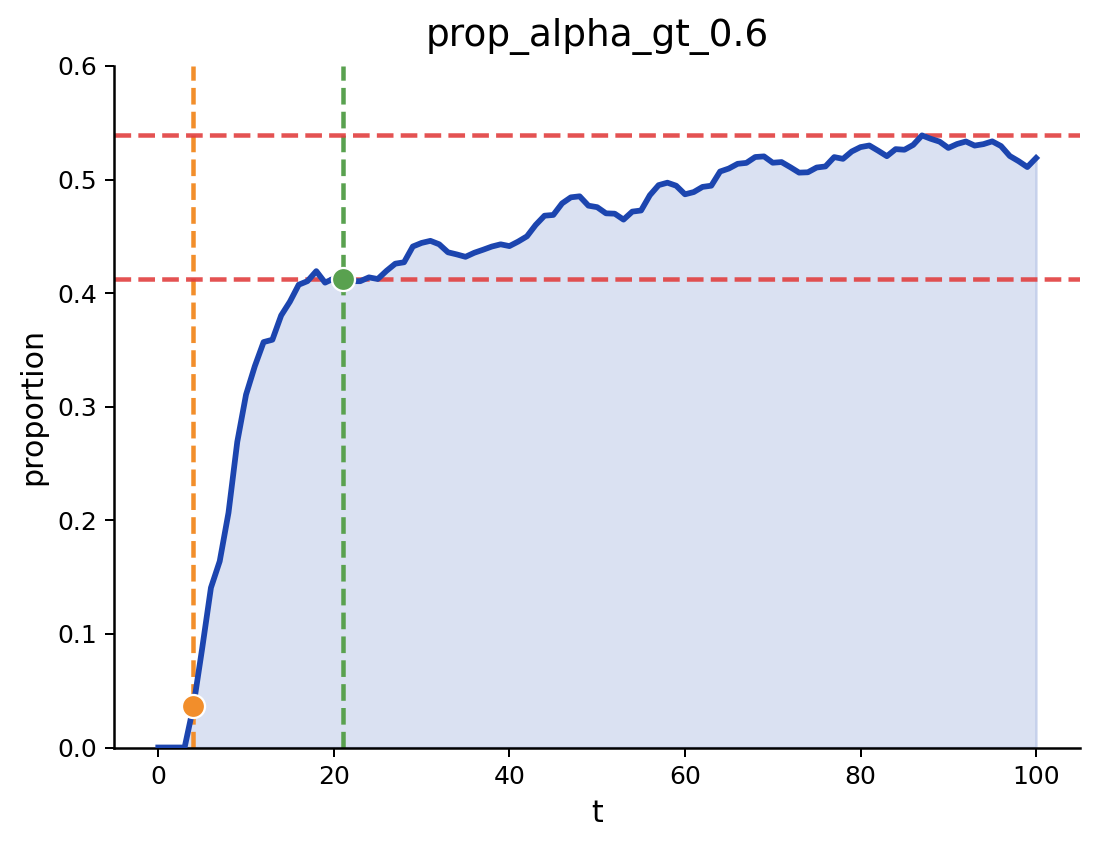

>> Summary saved to: /home/zhouyj/stVirtual_revision/R2/C9/LUAD/results/top10_results/alpha_threshold_summary.csv


In [47]:
first_positive_t, plateau_t, diag_piece, summary_piece = find_first_positive_and_plateau_by_piecewise(
    prop_df,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    positive_eps=1e-12,
    smooth=12,
    min_plateau_len=20,
)

print(summary_piece)

plot_prop_clean(
    diag_piece,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    first_positive_t=first_positive_t,
    plateau_t=plateau_t,
)
summary_piece.to_csv(os.path.join(save_dir, "alpha_threshold_summary.csv"), index=False)
print(f">> Summary saved to: {os.path.join(save_dir, 'alpha_threshold_summary.csv')}")

In [48]:
diag_piece.to_csv(session.start() / 'diag_piece1.csv',index=False)